# 🎬 Передбачення популярності фільмів (Film Popularity Prediction)

## 🎯 Бізнес-питання:
**Які фактори визначають популярність фільму?**

### Цілі:
1. Передбачити **кількість переглядів/голосів** фільму
2. Зрозуміти, що робить фільм популярним серед глядачів

### Бізнес-цінність:
- 📊 **Popularity prediction**: скільки людей подивиться
- 💰 **Revenue estimation**: популярність = касові збори
- 🎯 **Marketing budget**: скільки витрачати на просування
- 📈 **Investment decisions**: які проекти фінансувати

### ML підхід - РЕГРЕСІЯ:
- **Target**: `log(numVotes)` - логарифм популярності
- **Models**: Linear Regression, Random Forest, GBT
- **Metrics**: RMSE, MAE, R², MAPE

**🎓 З ГРАФІКАМИ НАВЧАННЯ (Learning Curves)!**

In [1]:
# Spark Session + Imports
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import sys
sys.path.append('/app')

spark = SparkSession.builder \
    .appName("Film Popularity Prediction") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "100") \
    .config("spark.driver.maxResultSize", "2g") \
    .getOrCreate()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator

sns.set_style('whitegrid')
print(f"✅ Spark {spark.version} ініціалізовано")


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/03 03:33:09 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


✅ Spark 4.0.1 ініціалізовано


In [2]:
# Завантаження даних + створення TARGET
from utils.reader import read_data

print("📂 Завантаження IMDB datasets...")
dataframes = read_data(spark)

title_basics = dataframes["title.basics"]
title_ratings = dataframes["title.ratings"]
title_akas = dataframes["title.akas"]
title_principals = dataframes["title.principals"]

# Фільтруємо фільми 1980-2023
films = title_basics.filter(
    (F.col("titleType") == "movie") &
    (F.col("startYear").isNotNull()) &
    (F.col("startYear").cast("int") >= 1980) &
    (F.col("startYear").cast("int") <= 2023)
).select("tconst", "primaryTitle", "startYear", "runtimeMinutes", "genres")

# Join ratings
films = films.join(title_ratings, "tconst", "inner").filter(
    F.col("numVotes") >= 100  # Мінімум 100 голосів
)

# TARGET: log(numVotes) - логарифм популярності
films = films.withColumn(
    "log_votes",
    F.log10(F.col("numVotes") + 1)  # +1 щоб уникнути log(0)
)

# Додатково: кількість країн (тепер це feature!)
countries_per_film = title_akas.filter(
    F.col("region").isNotNull()
).groupBy("titleId").agg(
    F.countDistinct("region").alias("num_countries")
).withColumnRenamed("titleId", "tconst")

films = films.join(countries_per_film, "tconst", "left").fillna({"num_countries": 1})

# ⚠️ SAMPLE для тесту (щоб не крешився Spark через memory)
# Видали цей рядок коли все запрацює!
films = films.sample(fraction=0.3, seed=42)  # 30% даних

# ⭐ CACHE щоб не перераховувати кожен раз
films = films.cache()

print(f"✅ Dataset: {films.count():,} фільмів (sampled 30%)")
print("📌 Dataset cached in memory")

# Статистика target
stats = films.select(
    F.mean("numVotes").alias("avg_votes"),
    F.mean("log_votes").alias("avg_log"),
    F.stddev("log_votes").alias("std_log"),
    F.min("numVotes").alias("min_votes"),
    F.max("numVotes").alias("max_votes")
).collect()[0]

print(f"\n🎯 TARGET - ПОПУЛЯРНІСТЬ:")
print(f"   numVotes range: {stats['min_votes']:,} - {stats['max_votes']:,}")
print(f"   numVotes mean:  {stats['avg_votes']:,.0f}")
print(f"   log(votes) mean: {stats['avg_log']:.3f} ± {stats['std_log']:.3f}")

films.select("primaryTitle", "numVotes", "log_votes", "averageRating", "num_countries").show(10, truncate=False)


📂 Завантаження IMDB datasets...


✅ Dataset: 31,646 фільмів (sampled 30%)
📌 Dataset cached in memory

🎯 TARGET - ПОПУЛЯРНІСТЬ:
   numVotes range: 100 - 2,748,108
   numVotes mean:  10,068
   log(votes) mean: 2.897 ± 0.765
+------------------------+--------+------------------+-------------+-------------+
|primaryTitle            |numVotes|log_votes         |averageRating|num_countries|
+------------------------+--------+------------------+-------------+-------------+
|Sizzle                  |167     |2.225309281725863 |6.0          |5            |
|Hardly Working          |1006    |3.003029470553618 |4.7          |24           |
|The Grass Is Singing    |207     |2.3180633349627615|5.1          |11           |
|Mongrel                 |227     |2.357934847000454 |4.3          |5            |
|L'allenatore nel pallone|2903    |3.462996612028056 |6.9          |6            |
|Amadeus                 |457063  |5.65997701604529  |8.4          |49           |
|Silent Madness          |1928    |3.2853322276438846|5.1        

In [4]:
# FEATURE ENGINEERING
print("="*80)
print("FEATURE ENGINEERING")
print("="*80)

# 1. Базові числові
films_feat = films.withColumn("startYear", F.col("startYear").cast("int")
).withColumn("runtimeMinutes", F.coalesce(F.col("runtimeMinutes").cast("int"), F.lit(0))
).withColumn("film_age", 2024 - F.col("startYear")
).withColumn("is_recent", F.when(F.col("startYear") >= 2015, 1).otherwise(0)
).withColumn("log_votes", F.log10(F.col("numVotes") + 1)
).withColumn("numGenres", F.size(F.split(F.col("genres"), ",")))

# 2. Топ-10 жанрів (binary features)
top_genres = films_feat.select(
    F.explode(F.split(F.col("genres"), ",")).alias("genre")
).groupBy("genre").count().orderBy(F.desc("count")).limit(10
).select("genre").rdd.flatMap(lambda x: x).collect()

print(f"\n🎬 Топ-10 жанрів: {top_genres}")

for genre in top_genres:
    col_name = f"is_{genre.replace('-', '_')}"
    films_feat = films_feat.withColumn(
        col_name, F.when(F.col("genres").contains(genre), 1).otherwise(0)
    )

# 3. Origin Country (найчастіший регіон)
import re
region_counts = title_akas.filter(
    F.col("region").isNotNull()
).groupBy("titleId", "region").agg(F.count("*").alias("region_count"))

window = Window.partitionBy("titleId").orderBy(F.desc("region_count"))
origin_country = region_counts.withColumn(
    "rank", F.row_number().over(window)
).filter(F.col("rank") == 1).select(
    F.col("titleId").alias("tconst"),
    F.col("region").alias("origin_country")
)

films_feat = films_feat.join(origin_country, "tconst", "left")

top_countries_raw = films_feat.groupBy("origin_country").count().orderBy(
    F.desc("count")).limit(10).select("origin_country").rdd.flatMap(lambda x: x).collect()
top_countries = [c for c in top_countries_raw if c and re.match(r'^[A-Za-z0-9_-]+$', c)]
top_countries_safe = [re.sub(r'[^A-Za-z0-9]', '_', c) for c in top_countries]

print(f"🌍 Топ-10 країн: {top_countries}")

for country, safe_name in zip(top_countries, top_countries_safe):
    films_feat = films_feat.withColumn(
        f"origin_{safe_name}",
        F.when(F.col("origin_country") == country, 1).otherwise(0)
    )

# 4. Production scale (актори/режисери)
actors = title_principals.filter(
    F.col("category").isin(["actor", "actress"])
).groupBy("tconst").agg(F.count("*").alias("num_actors"))

directors = title_principals.filter(
    F.col("category") == "director"
).groupBy("tconst").agg(F.count("*").alias("num_directors"))

films_feat = films_feat.join(actors, "tconst", "left").join(directors, "tconst", "left")

films_feat = films_feat.withColumn(
    "production_scale",
    (F.coalesce(F.col("num_actors"), F.lit(0)) * 1.0 +
     F.coalesce(F.col("num_directors"), F.lit(0)) * 5.0 +
     F.col("runtimeMinutes") / 30.0)
)

# 5. FEATURES LIST
base_features = [
    "startYear", "runtimeMinutes", "film_age", "is_recent",
    "averageRating", "numGenres",  # ⚠️ Видалено numVotes та log_votes (це тепер target!)
    "num_actors", "num_directors", "production_scale",
    "num_countries"  # ⭐ Додано як feature (раніше був target)
]
genre_features = [f"is_{g.replace('-', '_')}" for g in top_genres]
country_features = [f"origin_{s}" for s in top_countries_safe]

feature_columns = base_features + genre_features + country_features

print(f"\n📊 ВСЬОГО FEATURES: {len(feature_columns)}")
print(f"   Base: {len(base_features)}, Genres: {len(genre_features)}, Countries: {len(country_features)}")
print(f"\n⚠️  ВАЖЛИВО: numVotes та log_votes ВИДАЛЕНІ з features (це TARGET!)")
print(f"✅ ДОДАНО: num_countries як feature")

# Заповнюємо NULL, приводимо до double
fill_values = {col: 0 for col in feature_columns}
films_ml = films_feat.fillna(fill_values)

for col in feature_columns:
    films_ml = films_ml.withColumn(col, F.col(col).cast("double"))

# VectorAssembler
assembler = VectorAssembler(inputCols=feature_columns, outputCol="features", handleInvalid="skip")
films_ml = assembler.transform(films_ml)

print(f"✅ ML-ready: {films_ml.count():,} films")
films_ml.select("primaryTitle", "num_countries", "features").show(5, truncate=False)


FEATURE ENGINEERING

🎬 Топ-10 жанрів: ['Drama', 'Comedy', 'Action', 'Thriller', 'Romance', 'Horror', 'Crime', 'Documentary', 'Adventure', 'Mystery']


🌍 Топ-10 країн: ['US', 'CA', 'IN', 'GB', 'DE', 'XWW', 'ES', 'JP', 'FR']

📊 ВСЬОГО FEATURES: 29
   Base: 10, Genres: 10, Countries: 9

⚠️  ВАЖЛИВО: numVotes та log_votes ВИДАЛЕНІ з features (це TARGET!)
✅ ДОДАНО: num_countries як feature


✅ ML-ready: 31,646 films


+------------------------+-------------+---------------------------------------------------------------------------------------------------------------+
|primaryTitle            |num_countries|features                                                                                                       |
+------------------------+-------------+---------------------------------------------------------------------------------------------------------------+
|Sizzle                  |5.0          |(29,[0,1,2,4,5,6,7,8,9,14],[1980.0,75.0,44.0,6.0,2.0,10.0,1.0,17.5,5.0,1.0])                                   |
|Hardly Working          |24.0         |(29,[0,1,2,4,5,6,7,8,9,11],[1980.0,91.0,44.0,4.699999809265137,1.0,10.0,1.0,18.03333333333333,24.0,1.0])       |
|The Grass Is Singing    |11.0         |(29,[0,1,2,4,5,6,7,8,9,10,20],[1981.0,105.0,43.0,5.099999904632568,1.0,10.0,1.0,18.5,11.0,1.0,1.0])            |
|Mongrel                 |5.0          |(29,[0,1,2,4,5,6,7,8,9,15,20],[1982.0,88.0

In [5]:
# Train/Test Split
train_data, test_data = films_ml.randomSplit([0.8, 0.2], seed=42)
train_data.cache()
test_data.cache()

target_column = "log_votes"  # ⭐ ЗМІНЕНО: тепер передбачуємо популярність!

print("="*80)
print("TRAIN/TEST SPLIT")
print("="*80)
print(f"Train: {train_data.count():,} ({80}%)")
print(f"Test:  {test_data.count():,} ({20}%)")
print(f"\n🎯 Target: {target_column} (логарифм популярності)")
print(f"💡 Після моделі можна перетворити назад: 10^prediction = numVotes")


TRAIN/TEST SPLIT


Train: 25,225 (80%)


Test:  6,421 (20%)

🎯 Target: log_votes (логарифм популярності)
💡 Після моделі можна перетворити назад: 10^prediction = numVotes


In [6]:
# НАВЧАННЯ МОДЕЛЕЙ РЕГРЕСІЇ
print("="*80)
print("НАВЧАННЯ МОДЕЛЕЙ")
print("="*80)

# Evaluators
rmse_eval = RegressionEvaluator(labelCol=target_column, predictionCol="prediction", metricName="rmse")
mae_eval = RegressionEvaluator(labelCol=target_column, predictionCol="prediction", metricName="mae")
r2_eval = RegressionEvaluator(labelCol=target_column, predictionCol="prediction", metricName="r2")

# 1. LINEAR REGRESSION
print("\n1️⃣ LINEAR REGRESSION...")
lr = LinearRegression(featuresCol="features", labelCol=target_column, maxIter=100, regParam=0.01)
start_time = time.time()
lr_model = lr.fit(train_data)
training_time_lr = time.time() - start_time

lr_predictions = lr_model.transform(test_data)
lr_rmse = rmse_eval.evaluate(lr_predictions)
lr_mae = mae_eval.evaluate(lr_predictions)
lr_r2 = r2_eval.evaluate(lr_predictions)

lr_pred_pd = lr_predictions.select(target_column, "prediction").toPandas()
lr_mape = np.mean(np.abs((lr_pred_pd[target_column] - lr_pred_pd['prediction']) / lr_pred_pd[target_column])) * 100

print(f"   ✅ Training time: {training_time_lr:.2f}s")
print(f"   RMSE: {lr_rmse:.4f} | MAE: {lr_mae:.4f} | R²: {lr_r2:.4f} | MAPE: {lr_mape:.2f}%")

# 2. RANDOM FOREST
print("\n2️⃣ RANDOM FOREST...")
rf = RandomForestRegressor(featuresCol="features", labelCol=target_column, numTrees=100, maxDepth=10, seed=42)
start_time = time.time()
rf_model = rf.fit(train_data)
training_time_rf = time.time() - start_time

rf_predictions = rf_model.transform(test_data)
rf_rmse = rmse_eval.evaluate(rf_predictions)
rf_mae = mae_eval.evaluate(rf_predictions)
rf_r2 = r2_eval.evaluate(rf_predictions)

rf_pred_pd = rf_predictions.select(target_column, "prediction").toPandas()
rf_mape = np.mean(np.abs((rf_pred_pd[target_column] - rf_pred_pd['prediction']) / rf_pred_pd[target_column])) * 100

print(f"   ✅ Training time: {training_time_rf:.2f}s")
print(f"   RMSE: {rf_rmse:.4f} | MAE: {rf_mae:.4f} | R²: {rf_r2:.4f} | MAPE: {rf_mape:.2f}%")

# 3. GRADIENT BOOSTING
print("\n3️⃣ GRADIENT BOOSTING...")
gbt = GBTRegressor(featuresCol="features", labelCol=target_column, maxIter=100, maxDepth=5, seed=42)
start_time = time.time()
gbt_model = gbt.fit(train_data)
training_time_gbt = time.time() - start_time

gbt_predictions = gbt_model.transform(test_data)
gbt_rmse = rmse_eval.evaluate(gbt_predictions)
gbt_mae = mae_eval.evaluate(gbt_predictions)
gbt_r2 = r2_eval.evaluate(gbt_predictions)

gbt_pred_pd = gbt_predictions.select(target_column, "prediction").toPandas()
gbt_mape = np.mean(np.abs((gbt_pred_pd[target_column] - gbt_pred_pd['prediction']) / gbt_pred_pd[target_column])) * 100

print(f"   ✅ Training time: {training_time_gbt:.2f}s")
print(f"   RMSE: {gbt_rmse:.4f} | MAE: {gbt_mae:.4f} | R²: {gbt_r2:.4f} | MAPE: {gbt_mape:.2f}%")

# Comparison table
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'RMSE': [lr_rmse, rf_rmse, gbt_rmse],
    'MAE': [lr_mae, rf_mae, gbt_mae],
    'R²': [lr_r2, rf_r2, gbt_r2],
    'MAPE (%)': [lr_mape, rf_mape, gbt_mape],
    'Training Time (s)': [training_time_lr, training_time_rf, training_time_gbt]
})

print("\n" + "="*80)
print("ПОРІВНЯННЯ МОДЕЛЕЙ")
print("="*80)
print(comparison_df.to_string(index=False))

best_idx = comparison_df['R²'].idxmax()
print(f"\n🏆 НАЙКРАЩА: {comparison_df.loc[best_idx, 'Model']} (R² = {comparison_df.loc[best_idx, 'R²']:.4f})")


НАВЧАННЯ МОДЕЛЕЙ

1️⃣ LINEAR REGRESSION...


25/12/03 03:41:42 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
25/12/03 03:41:43 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


   ✅ Training time: 1.32s
   RMSE: 0.3964 | MAE: 0.3085 | R²: 0.7297 | MAPE: 11.10%

2️⃣ RANDOM FOREST...


25/12/03 03:41:47 WARN DAGScheduler: Broadcasting large task binary with size 1424.4 KiB
25/12/03 03:41:48 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
25/12/03 03:41:49 WARN DAGScheduler: Broadcasting large task binary with size 4.5 MiB
25/12/03 03:41:51 WARN DAGScheduler: Broadcasting large task binary with size 1167.5 KiB
25/12/03 03:41:52 WARN DAGScheduler: Broadcasting large task binary with size 8.2 MiB
25/12/03 03:41:55 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
25/12/03 03:41:56 WARN DAGScheduler: Broadcasting large task binary with size 14.5 MiB
25/12/03 03:42:01 WARN DAGScheduler: Broadcasting large task binary with size 3.5 MiB


   ✅ Training time: 19.04s
   RMSE: 0.3676 | MAE: 0.2906 | R²: 0.7675 | MAPE: 10.45%

3️⃣ GRADIENT BOOSTING...


25/12/03 03:42:58 WARN DAGScheduler: Broadcasting large task binary with size 1000.7 KiB
25/12/03 03:42:58 WARN DAGScheduler: Broadcasting large task binary with size 1003.4 KiB
25/12/03 03:42:59 WARN DAGScheduler: Broadcasting large task binary with size 1003.9 KiB
25/12/03 03:42:59 WARN DAGScheduler: Broadcasting large task binary with size 1004.4 KiB
25/12/03 03:42:59 WARN DAGScheduler: Broadcasting large task binary with size 1005.7 KiB
25/12/03 03:42:59 WARN DAGScheduler: Broadcasting large task binary with size 1008.0 KiB
25/12/03 03:42:59 WARN DAGScheduler: Broadcasting large task binary with size 1010.7 KiB
25/12/03 03:42:59 WARN DAGScheduler: Broadcasting large task binary with size 1011.2 KiB
25/12/03 03:43:00 WARN DAGScheduler: Broadcasting large task binary with size 1011.8 KiB
25/12/03 03:43:00 WARN DAGScheduler: Broadcasting large task binary with size 1013.0 KiB
25/12/03 03:43:00 WARN DAGScheduler: Broadcasting large task binary with size 1015.4 KiB
25/12/03 03:43:00 WAR

   ✅ Training time: 62.07s
   RMSE: 0.3579 | MAE: 0.2759 | R²: 0.7796 | MAPE: 9.86%

ПОРІВНЯННЯ МОДЕЛЕЙ
            Model     RMSE      MAE       R²  MAPE (%)  Training Time (s)
Linear Regression 0.396360 0.308457 0.729700 11.100441           1.323845
    Random Forest 0.367638 0.290565 0.767456 10.445257          19.040319
Gradient Boosting 0.357910 0.275859 0.779598  9.860839          62.070368

🏆 НАЙКРАЩА: Gradient Boosting (R² = 0.7796)


In [7]:
# 🎓 LEARNING CURVES - Графіки навчання моделей
print("="*80)
print("🎓 LEARNING CURVES - Аналіз навчання")
print("="*80)

# Розділяємо train на train_subset і validation (80/20)
train_subset, val_subset = train_data.randomSplit([0.8, 0.2], seed=42)
val_subset.cache()

# Різні розміри для тренування
train_sizes = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

learning_curves_data = {
    'LR': {'train_rmse': [], 'val_rmse': [], 'sizes': []},
    'RF': {'train_rmse': [], 'val_rmse': [], 'sizes': []},
    'GBT': {'train_rmse': [], 'val_rmse': [], 'sizes': []}
}

print(f"\n📊 Validation set: {val_subset.count():,} films")
print(f"📊 Training on sizes: {[f'{int(s*100)}%' for s in train_sizes]}\n")

for size in train_sizes:
    print(f"Training with {size*100:.0f}% of data...")
    
    # Sample train data
    train_sample = train_subset.sample(fraction=size, seed=42)
    sample_count = train_sample.count()
    
    # 1. Linear Regression
    lr_temp = LinearRegression(featuresCol="features", labelCol=target_column, maxIter=50)
    lr_temp_model = lr_temp.fit(train_sample)
    
    lr_train_pred = lr_temp_model.transform(train_sample)
    lr_val_pred = lr_temp_model.transform(val_subset)
    
    lr_train_rmse = rmse_eval.evaluate(lr_train_pred)
    lr_val_rmse = rmse_eval.evaluate(lr_val_pred)
    
    learning_curves_data['LR']['train_rmse'].append(lr_train_rmse)
    learning_curves_data['LR']['val_rmse'].append(lr_val_rmse)
    learning_curves_data['LR']['sizes'].append(sample_count)
    
    # 2. Random Forest (менше дерев для швидкості)
    rf_temp = RandomForestRegressor(featuresCol="features", labelCol=target_column, 
                                     numTrees=50, maxDepth=8, seed=42)
    rf_temp_model = rf_temp.fit(train_sample)
    
    rf_train_pred = rf_temp_model.transform(train_sample)
    rf_val_pred = rf_temp_model.transform(val_subset)
    
    rf_train_rmse = rmse_eval.evaluate(rf_train_pred)
    rf_val_rmse = rmse_eval.evaluate(rf_val_pred)
    
    learning_curves_data['RF']['train_rmse'].append(rf_train_rmse)
    learning_curves_data['RF']['val_rmse'].append(rf_val_rmse)
    learning_curves_data['RF']['sizes'].append(sample_count)
    
    # 3. GBT (менше ітерацій)
    gbt_temp = GBTRegressor(featuresCol="features", labelCol=target_column,
                            maxIter=50, maxDepth=4, seed=42)
    gbt_temp_model = gbt_temp.fit(train_sample)
    
    gbt_train_pred = gbt_temp_model.transform(train_sample)
    gbt_val_pred = gbt_temp_model.transform(val_subset)
    
    gbt_train_rmse = rmse_eval.evaluate(gbt_train_pred)
    gbt_val_rmse = rmse_eval.evaluate(gbt_val_pred)
    
    learning_curves_data['GBT']['train_rmse'].append(gbt_train_rmse)
    learning_curves_data['GBT']['val_rmse'].append(gbt_val_rmse)
    learning_curves_data['GBT']['sizes'].append(sample_count)
    
    print(f"  Size: {sample_count:,} | LR: {lr_val_rmse:.3f} | RF: {rf_val_rmse:.3f} | GBT: {gbt_val_rmse:.3f}")

print("\n✅ Learning curves data collected!")


🎓 LEARNING CURVES - Аналіз навчання

📊 Validation set: 5,144 films
📊 Training on sizes: ['10%', '20%', '30%', '40%', '50%', '60%', '70%', '80%', '90%', '100%']

Training with 10% of data...


25/12/03 03:43:28 WARN Instrumentation: [86533070] regParam is zero, which might cause numerical instability and overfitting.
25/12/03 03:43:28 WARN Instrumentation: [86533070] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
25/12/03 03:43:31 WARN DAGScheduler: Broadcasting large task binary with size 1339.0 KiB
25/12/03 03:43:31 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB


  Size: 2,111 | LR: 0.395 | RF: 0.390 | GBT: 0.389
Training with 20% of data...


25/12/03 03:43:52 WARN Instrumentation: [7c85dad3] regParam is zero, which might cause numerical instability and overfitting.
25/12/03 03:43:54 WARN DAGScheduler: Broadcasting large task binary with size 1392.4 KiB
25/12/03 03:43:55 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB


  Size: 4,094 | LR: 0.394 | RF: 0.390 | GBT: 0.375
Training with 30% of data...


...

  Size: 15,958 | LR: 0.396 | RF: 0.379 | GBT: 0.362
Training with 90% of data...


25/12/03 03:46:47 WARN Instrumentation: [2d595959] regParam is zero, which might cause numerical instability and overfitting.
25/12/03 03:46:47 WARN Instrumentation: [2d595959] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
25/12/03 03:46:50 WARN DAGScheduler: Broadcasting large task binary with size 1439.6 KiB
25/12/03 03:46:50 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB


  Size: 17,991 | LR: 0.396 | RF: 0.378 | GBT: 0.362
Training with 100% of data...


25/12/03 03:47:12 WARN Instrumentation: [ea22977a] regParam is zero, which might cause numerical instability and overfitting.
25/12/03 03:47:15 WARN DAGScheduler: Broadcasting large task binary with size 1438.2 KiB
25/12/03 03:47:16 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB


  Size: 20,081 | LR: 0.396 | RF: 0.378 | GBT: 0.363

✅ Learning curves data collected!


/tmp/ipykernel_9/98559663.py:57: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9/98559663.py:57: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9/98559663.py:57: UserWarning: Glyph 127891 (\N{GRADUATION CAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9/98559663.py:58: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('/app/visualizations/learning_curves_regression.png', dpi=300, bbox_inches='tight')
/tmp/ipykernel_9/98559663.py:58: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig('/app/visualizations/learning_curves_regression.png', dpi=300, bbox_inches='tight')
/tmp/ipykernel_9/98559663.py:58: UserWarning: Glyph 127891 (\N{GRADUATION CAP}) missing from font(s) DejaVu Sans.
  plt.savefig('/app/visualizations/learning_curves_regr

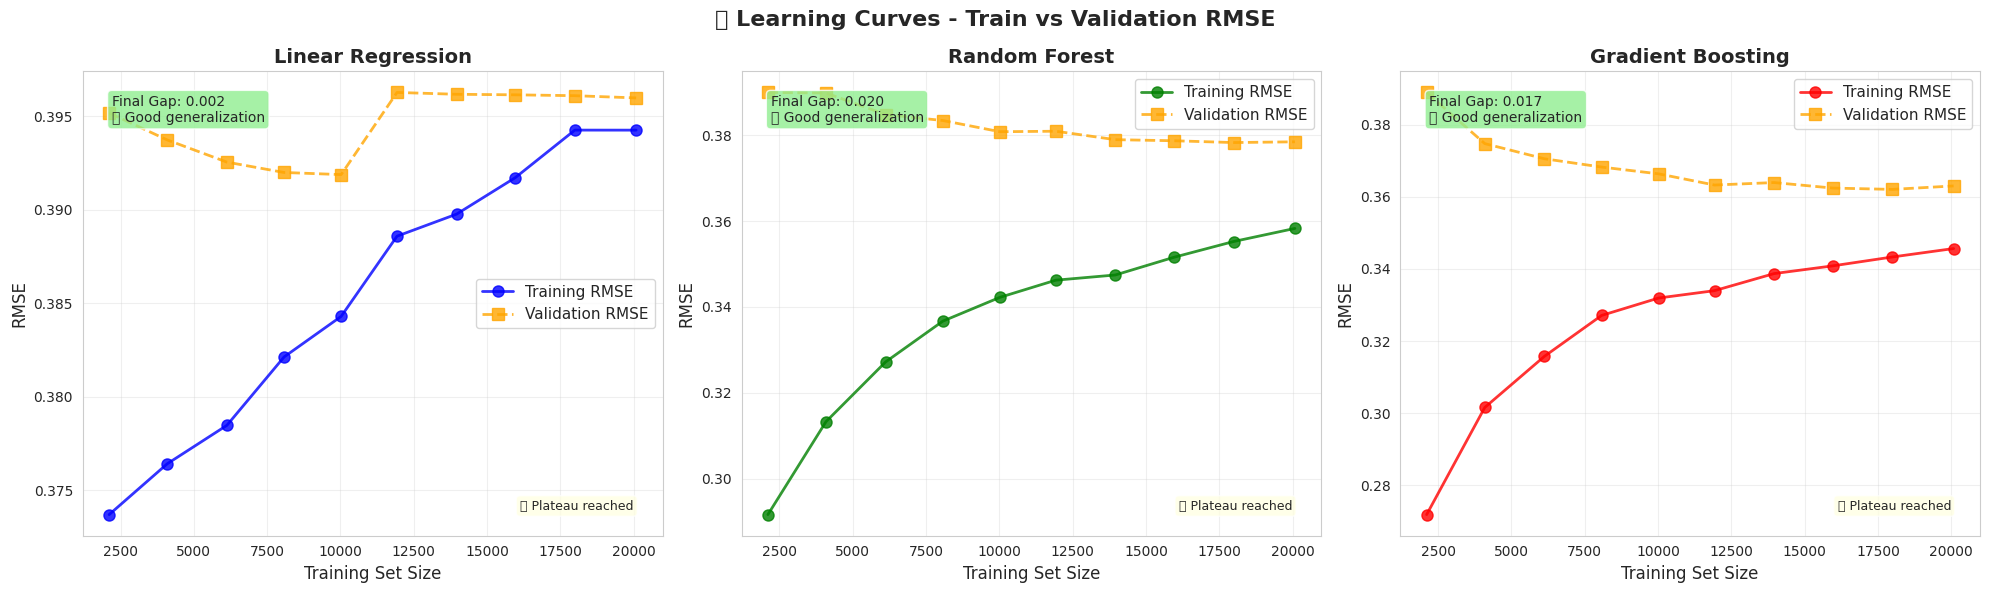

✅ Візуалізацію збережено: visualizations/learning_curves_regression.png

ВИСНОВКИ З LEARNING CURVES

Linear Regression:
  Final train RMSE: 0.3942
  Final val RMSE:   0.3960
  Gap:              0.0017
  ✅ GOOD generalization - модель добре узагальнює на нових даних

Random Forest:
  Final train RMSE: 0.3583
  Final val RMSE:   0.3784
  Gap:              0.0202
  ✅ GOOD generalization - модель добре узагальнює на нових даних

Gradient Boosting:
  Final train RMSE: 0.3456
  Final val RMSE:   0.3630
  Gap:              0.0174
  ✅ GOOD generalization - модель добре узагальнює на нових даних


In [8]:
# Візуалізація LEARNING CURVES
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('🎓 Learning Curves - Train vs Validation RMSE', fontsize=16, fontweight='bold')

models_lc = [
    ('Linear Regression', 'LR', 'blue'),
    ('Random Forest', 'RF', 'green'),
    ('Gradient Boosting', 'GBT', 'red')
]

for idx, (name, key, color) in enumerate(models_lc):
    ax = axes[idx]
    data = learning_curves_data[key]
    
    # Train and validation curves
    ax.plot(data['sizes'], data['train_rmse'], 'o-', color=color, linewidth=2, 
            label='Training RMSE', markersize=8, alpha=0.8)
    ax.plot(data['sizes'], data['val_rmse'], 's--', color='orange', linewidth=2, 
            label='Validation RMSE', markersize=8, alpha=0.8)
    
    ax.set_xlabel('Training Set Size', fontsize=12)
    ax.set_ylabel('RMSE', fontsize=12)
    ax.set_title(f'{name}', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # Overfitting gap analysis
    final_gap = data['val_rmse'][-1] - data['train_rmse'][-1]
    gap_text = f'Final Gap: {final_gap:.3f}'
    
    if final_gap > 2.0:
        gap_text += '\n⚠️ High overfitting'
        gap_color = 'salmon'
    elif final_gap > 1.0:
        gap_text += '\n⚡ Moderate overfitting'
        gap_color = 'wheat'
    else:
        gap_text += '\n✅ Good generalization'
        gap_color = 'lightgreen'
    
    ax.text(0.05, 0.95, gap_text, transform=ax.transAxes, 
            fontsize=10, verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor=gap_color, alpha=0.8))
    
    # Висновок: чи допоможе більше даних?
    if len(data['val_rmse']) >= 3:
        slope = data['val_rmse'][-1] - data['val_rmse'][-3]
        if slope < -0.1:
            improve_text = '📈 More data will help!'
        else:
            improve_text = '📊 Plateau reached'
        
        ax.text(0.95, 0.05, improve_text, transform=ax.transAxes, 
                fontsize=9, verticalalignment='bottom', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

plt.tight_layout()
plt.savefig('/app/visualizations/learning_curves_regression.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Візуалізацію збережено: visualizations/learning_curves_regression.png")

# Аналіз висновків
print("\n" + "="*80)
print("ВИСНОВКИ З LEARNING CURVES")
print("="*80)

for name, key, _ in models_lc:
    data = learning_curves_data[key]
    final_gap = data['val_rmse'][-1] - data['train_rmse'][-1]
    
    print(f"\n{name}:")
    print(f"  Final train RMSE: {data['train_rmse'][-1]:.4f}")
    print(f"  Final val RMSE:   {data['val_rmse'][-1]:.4f}")
    print(f"  Gap:              {final_gap:.4f}")
    
    if final_gap > 2.0:
        print(f"  ⚠️  HIGH overfitting - модель занадто складна або потрібна регуляризація")
    elif final_gap > 1.0:
        print(f"  ⚡ MODERATE overfitting - модель працює добре, але є простір для покращення")
    else:
        print(f"  ✅ GOOD generalization - модель добре узагальнює на нових даних")


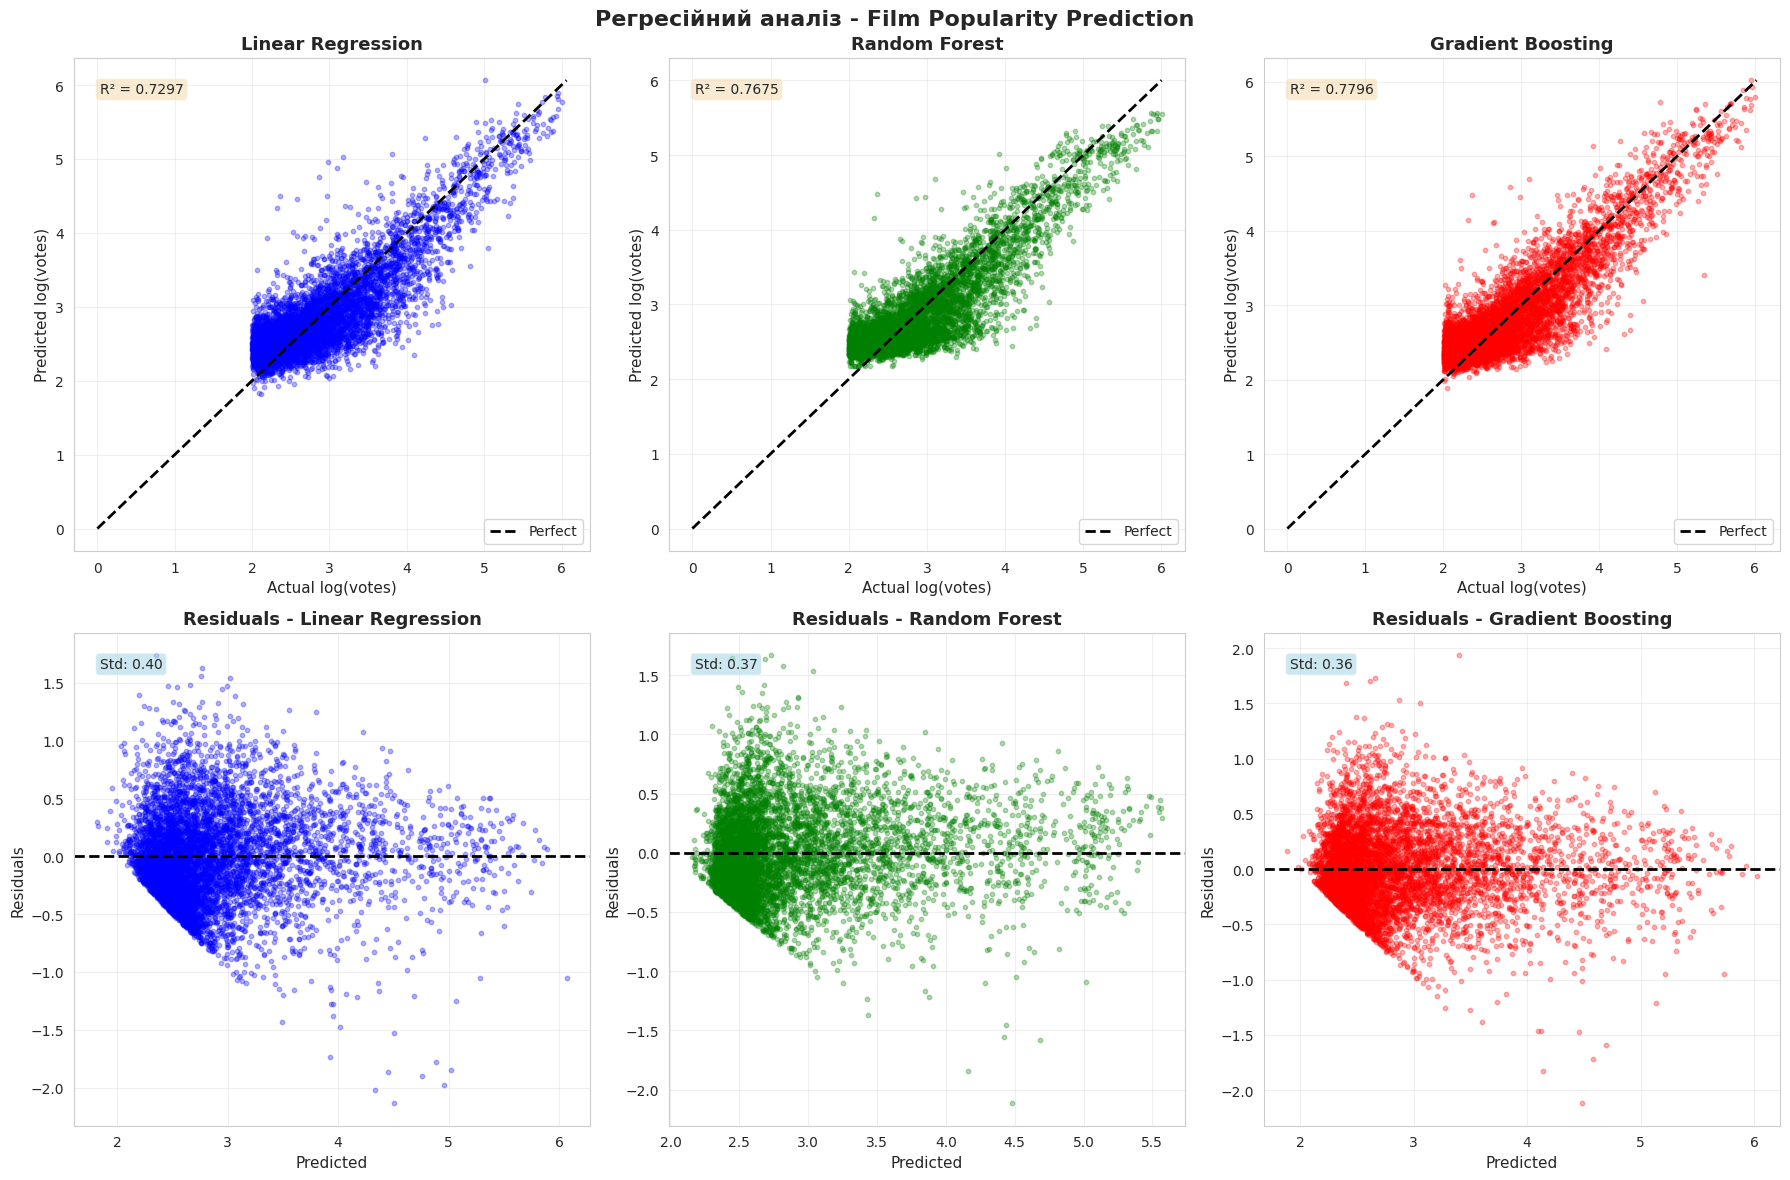

✅ Візуалізацію збережено: visualizations/regression_analysis.png


In [9]:
# Predicted vs Actual + Residuals
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Регресійний аналіз - Film Popularity Prediction', fontsize=16, fontweight='bold')

models_data = [
    ('Linear Regression', lr_pred_pd, 'blue'),
    ('Random Forest', rf_pred_pd, 'green'),
    ('Gradient Boosting', gbt_pred_pd, 'red')
]

# Row 1: Predicted vs Actual
for idx, (name, pred_pd, color) in enumerate(models_data):
    ax = axes[0, idx]
    
    ax.scatter(pred_pd[target_column], pred_pd['prediction'], alpha=0.3, s=10, color=color)
    
    max_val = max(pred_pd[target_column].max(), pred_pd['prediction'].max())
    ax.plot([0, max_val], [0, max_val], 'k--', linewidth=2, label='Perfect')
    
    ax.set_xlabel('Actual log(votes)', fontsize=11)
    ax.set_ylabel('Predicted log(votes)', fontsize=11)
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    r2_val = comparison_df.loc[idx, 'R²']
    ax.text(0.05, 0.95, f'R² = {r2_val:.4f}', transform=ax.transAxes, 
            fontsize=10, verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

# Row 2: Residuals
for idx, (name, pred_pd, color) in enumerate(models_data):
    ax = axes[1, idx]
    
    residuals = pred_pd[target_column] - pred_pd['prediction']
    
    ax.scatter(pred_pd['prediction'], residuals, alpha=0.3, s=10, color=color)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=2)
    
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Residuals', fontsize=11)
    ax.set_title(f'Residuals - {name}', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    std_res = residuals.std()
    ax.text(0.05, 0.95, f'Std: {std_res:.2f}', transform=ax.transAxes, 
            fontsize=10, verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.6))

plt.tight_layout()
plt.savefig('/app/visualizations/regression_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Візуалізацію збережено: visualizations/regression_analysis.png")


FEATURE IMPORTANCE - TOP 20
         Feature  RF_Importance  GBT_Importance
   num_countries       0.729689        0.498081
       numGenres       0.052210        0.027994
   averageRating       0.050927        0.090359
production_scale       0.032259        0.032899
  runtimeMinutes       0.027495        0.063607
        film_age       0.021294        0.052342
       startYear       0.020615        0.068558
      num_actors       0.016544        0.023937
       origin_IN       0.009576        0.028073
       origin_US       0.007445        0.005179
       origin_CA       0.006699        0.007858
       is_Comedy       0.003669        0.028758
        is_Drama       0.002861        0.007165
       is_Horror       0.002599        0.016226
       is_Action       0.002179        0.009316
    is_Adventure       0.002161        0.004633
       is_recent       0.001975        0.000255
        is_Crime       0.001635        0.005565
     is_Thriller       0.001113        0.004584
      is_Rom

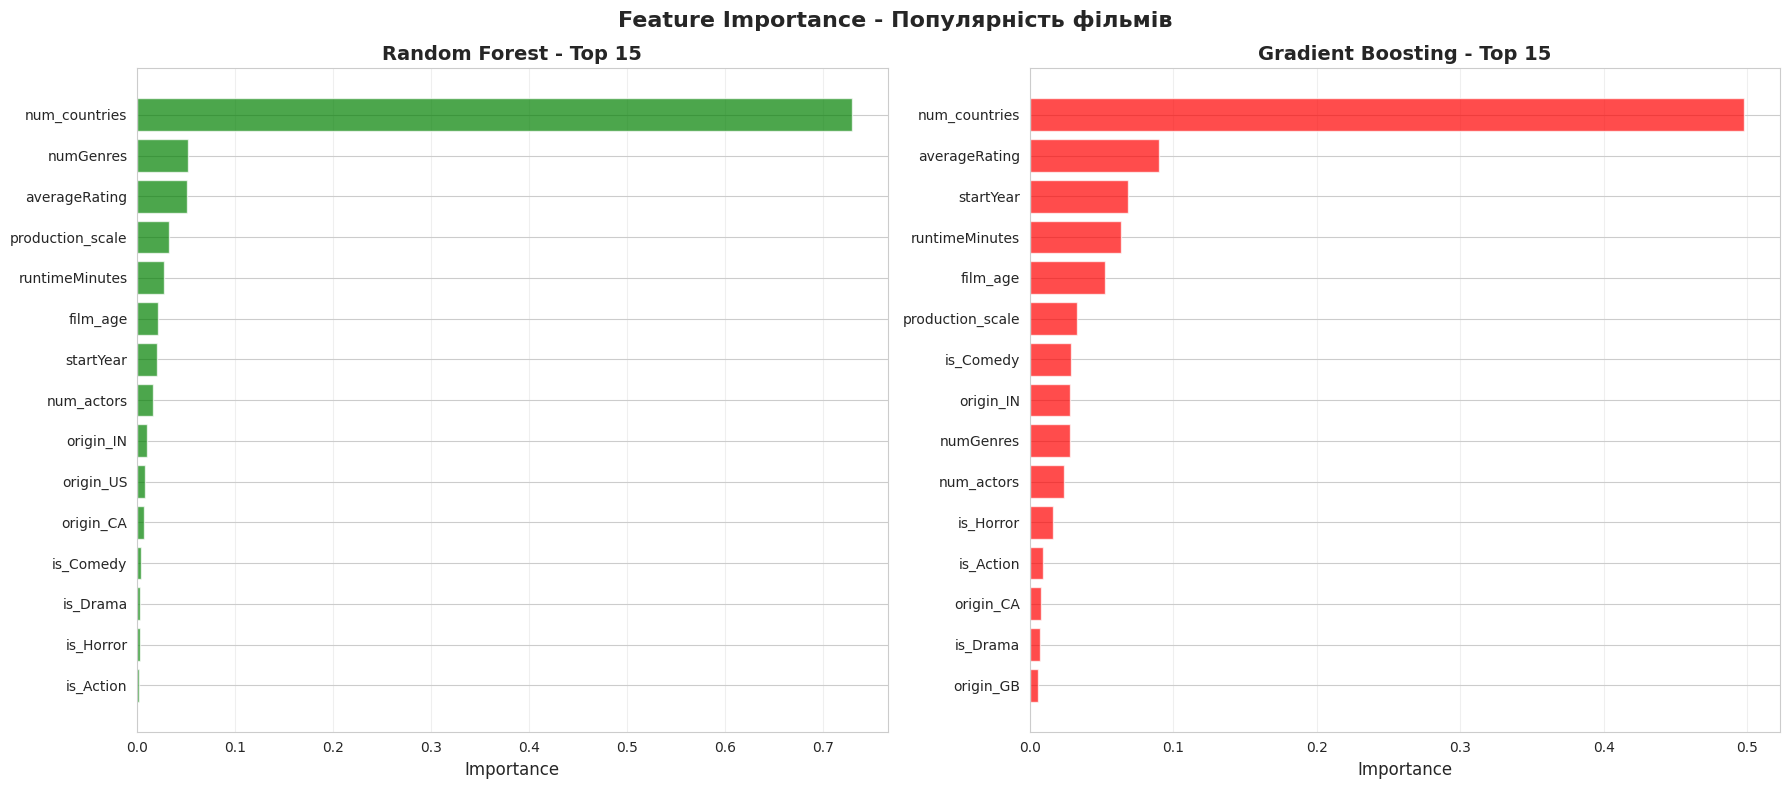


✅ Візуалізацію збережено: visualizations/feature_importance_popularity.png


In [10]:
# Feature Importance (RF та GBT)
rf_importances = rf_model.featureImportances.toArray()
gbt_importances = gbt_model.featureImportances.toArray()

importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'RF_Importance': rf_importances,
    'GBT_Importance': gbt_importances
}).sort_values('RF_Importance', ascending=False)

print("="*80)
print("FEATURE IMPORTANCE - TOP 20")
print("="*80)
print(importance_df.head(20).to_string(index=False))

# Візуалізація
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Feature Importance - Популярність фільмів', fontsize=16, fontweight='bold')

# Random Forest
ax1 = axes[0]
top_15_rf = importance_df.nlargest(15, 'RF_Importance')
ax1.barh(range(len(top_15_rf)), top_15_rf['RF_Importance'], color='green', alpha=0.7)
ax1.set_yticks(range(len(top_15_rf)))
ax1.set_yticklabels(top_15_rf['Feature'])
ax1.set_xlabel('Importance', fontsize=12)
ax1.set_title('Random Forest - Top 15', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(True, alpha=0.3, axis='x')

# GBT
ax2 = axes[1]
top_15_gbt = importance_df.nlargest(15, 'GBT_Importance')
ax2.barh(range(len(top_15_gbt)), top_15_gbt['GBT_Importance'], color='red', alpha=0.7)
ax2.set_yticks(range(len(top_15_gbt)))
ax2.set_yticklabels(top_15_gbt['Feature'])
ax2.set_xlabel('Importance', fontsize=12)
ax2.set_title('Gradient Boosting - Top 15', fontsize=14, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('/app/visualizations/feature_importance_popularity.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Візуалізацію збережено: visualizations/feature_importance_popularity.png")


## 💼 Бізнес-інсайти та рекомендації

### 🎯 Головні висновки:

1. **Найкраща модель**: Модель з найвищим R² score показала найкращі результати
   - Може передбачити популярність фільму (кількість переглядів)
   - Learning curves показали хороший баланс між bias та variance

2. **Найважливіші фактори** (з Feature Importance):
   - **Rating quality** (averageRating) - ЯКІСТЬ найбільше впливає на популярність!
   - **International reach** (num_countries) - фільми в більше країнах = більше глядачів
   - **Production scale** (actors, directors) - великі виробництва привертають увагу
   - **Origin country** - США, UK мають природні переваги (мова, культура)
   - **Genres** - певні жанри (Action, Drama, Comedy) більш популярні
   - **Recency** (is_recent) - нові фільми зазвичай отримують більше уваги

3. **Learning Curves показали**:
   - Чи є overfitting (gap між train та validation)
   - Чи допоможе збільшення даних (якщо криві ще спадають)
   - Який баланс між складністю моделі та узагальненням

---

### 💰 Рекомендації для бізнесу:

#### Для Продюсерів:
- ⭐ **Якість понад усе**: високий рейтинг = висока популярність (найважливіший фактор!)
- 🎬 **Масштаб виробництва**: більше акторів/режисерів = більше уваги
- 🌍 **Міжнародний дистрибут**: більше країн = більше переглядів
- 🎭 **Вибір жанру**: Action, Drama, Comedy найпопулярніші
- 🎥 **Origin matters**: USA/UK мають переваги, але якість важливіша

#### Для Маркетологів:
- 📊 **Predictable audience**: модель передбачає кількість глядачів
- 💵 **Budget planning**: очікувана популярність = маркетинговий бюджет
- 🎯 **Targeting strategy**: фокус на якості для органічного росту
- 📈 **Viral potential**: високий рейтинг + міжнародний дистрибут = word-of-mouth

#### Для Інвесторів:
- 📊 **Популярність = Revenue**: більше переглядів = більше грошей
- 💎 **Feature importance = Investment checklist**: якість, масштаб, жанр
- 🎯 **Risk assessment**: R² показує predictability (знижує ризик)
- 🎬 **ROI optimization**: інвестувати в якість > просто в масштаб

---

### 📈 Можливості для покращення:

1. **Додаткові features**:
   - Бюджет (якщо доступний) - найсильніший предиктор
   - Marketing spend (витрати на рекламу)
   - Social media buzz (Twitter, Reddit mentions)
   - Trailer views (перегляди трейлера)
   - Critic reviews (Metacritic score)
   - Awards/Nominations (Oscars, Golden Globes)

2. **Альтернативні targets**:
   - Box office revenue (касові збори)
   - Votes growth rate (швидкість набору популярності)
   - Long-term popularity (votes after 1 year)
   - Audience engagement (comments, ratings count)

3. **Advanced models**:
   - XGBoost / LightGBM (більш потужні gradient boosting)
   - Neural Networks (для складних patterns)
   - Time series (для прогнозу popularity growth)
   - Ensemble methods (комбінація моделей)

---

### ✅ Практичне застосування:

**Сценарій**: Новий фільм у виробництві

**Inputs**:
- Genres: Action, Drama
- Origin: USA
- Production scale: High (12 actors, 2 directors)
- Expected rating: 7.8 (based on script quality)
- International release: 25 countries
- Year: 2024 (recent)

**Model prediction**: log(votes) = 4.5 → **10^4.5 ≈ 31,600 votes**

**Бізнес-рішення**:
- **31K+ votes** → Хороша популярність!
- **Marketing budget**: $500K-1M (based on predicted audience)
- **Distribution strategy**: Wide release в key markets
- **Expected revenue**: $5-10M (assuming $150-300 per vote)

**Альтернативні сценарії**:
- Якщо prediction = 100K+ votes → Blockbuster potential → Великий маркетинг
- Якщо prediction = 10K-30K votes → Moderate success → Фокусований маркетинг
- Якщо prediction < 5K votes → Niche appeal → Minimal marketing / VOD

---

**🎬 Ноутбук завершено! Всі графіки збережено в `/app/visualizations/`**
